# (12) leapfrog: (32x2, 64.0x1.0)

project = ```iP-VAE```, host = ```chewie```, device = ```cuda:0```

**Motivation**: <br>

reproduce old result from yesterday using new code

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
# from analysis.eval import sparse_score
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from figures.analysis import plot_convergence
from figures.imgs import plot_weights


device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

## Trainer

In [3]:
cfg_vae, cfg_tr = default_configs('vH16', 'leapfrog|lin')
cfg_vae['seq_len'] = 32
cfg_vae['tbptt_steps'] = 32
cfg_vae['n_iters_inner'] = 2

cfg_vae['track_stats'] = True

cfg_vae['beta_inner'] = 1.0
cfg_tr['kl_beta'] = 64.0

cfg_tr['tbptt_accumulate'] = False

print(f"VAE:\n{cfg_vae}\n\nTrainer:\n{cfg_tr}")

VAE:
{'dataset': 'vH16', 'n_latents': 512, 'clamp_prior': -4, 'clamp_du': 7.0, 'clamp_u': 8.0, 'inf_type': 'leapfrog', 
'dec_type': 'lin', 'init_dist': 'normal', 'init_scale': 0.0001, 'seq_len': 32, 'tbptt_steps': 32, 'n_iters_inner': 
2, 'track_stats': True, 'beta_inner': 1.0}

Trainer:
{'batch_size': 200, 'epochs': 300, 'grad_clip': 200, 'kl_beta': 64.0, 'tbptt_accumulate': False}

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  132.9 K   |
|     ———     |    ———     |
|    layer    |  132.9 K   |
+-------------+------------+

vH16_t-32×2_b-1_z-[512]_<leapfrog|lin>
b200-ep300-lr(0.002)_beta(64:0.1)_temp(0.05:0.5)_gr(200)_(2025_02_12,22:14)

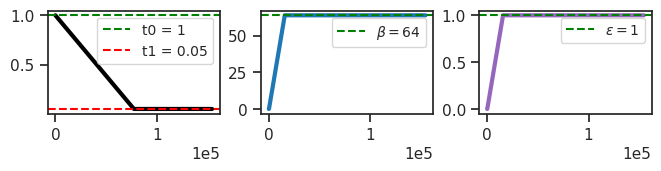

In [4]:
mod = IPVAE(ConfigPoisVAE(**cfg_vae))
tr = Trainer(mod, ConfigTrain(**cfg_tr), device=device)

mod.print()
print(f"{mod.cfg.name()}\n{tr.cfg.name()}_({mod.timestamp})\n")
tr.show_schedules()

In [5]:
print(tr.n_iters, tr.cfg.tbptt_accumulate)

154500 False

In [6]:
print(tr.model.layer)

PoissonLayer(input_dim=256,latent_dim=512, beta_inner=1, temp=1)

In [7]:
tr.model.layer.log_gamma, tr.model.layer.log_dt

(Parameter containing:
 tensor([0.], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([0.], device='cuda:0', requires_grad=True))

In [8]:
tr.model.layer.log_bias.shape, tr.model.layer.log_lr

(torch.Size([1, 512]),
 Parameter containing:
 tensor([0.], device='cuda:0', requires_grad=True))

In [9]:
cm = f"aim:reproduce_accumu={tr.cfg.tbptt_accumulate}"
tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

# tr.train()

epoch # 300, avg loss: 244.369953: 100%|████| 300/300 [7:50:34<00:00, 94.12s/it]


In [10]:
print(tr.model.layer.n_exp)

tensor([26, 31, 39, 50, 62, 73, 81, 87, 90, 91, 92, 92, 92, 92, 92, 92, 92, 92,
        91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 91],
       device='cuda:0', dtype=torch.int32)

## CONT. From Here

In [11]:
u_min = np.asarray(tr.model.stats['u_min'])
u_max = np.asarray(tr.model.stats['u_max'])
du_min = np.asarray(tr.model.stats['du_min'])
du_max = np.asarray(tr.model.stats['du_max'])

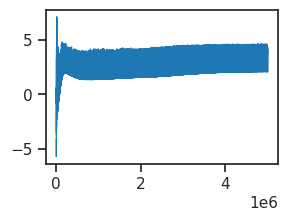

In [13]:
plt.plot(u_max, lw=0.8)

In [14]:
tr.model.layer.log_dt.exp(), tr.model.layer.log_gamma.exp()

(tensor([0.1998], device='cuda:0', grad_fn=<ExpBackward0>),
 tensor([2.6740], device='cuda:0', grad_fn=<ExpBackward0>))

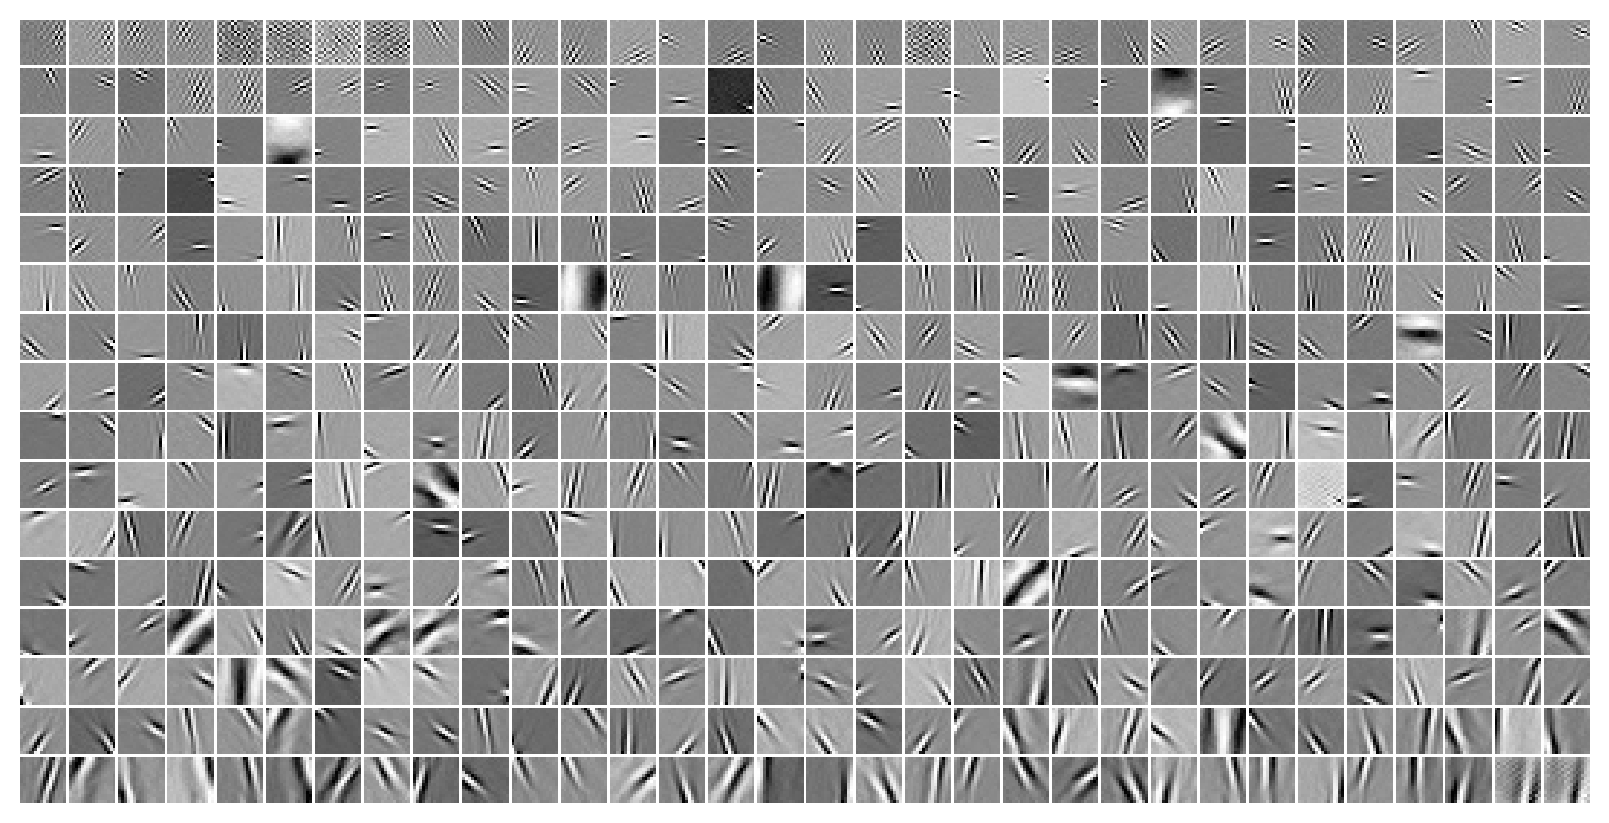

In [15]:
u0 = tonp(tr.model.layer.u_init.squeeze())
tr.model.show(order=np.argsort(u0));

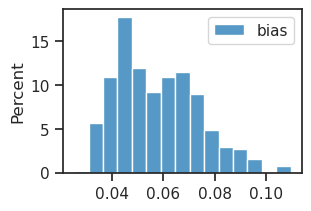

In [16]:
fig, ax = create_figure()

kws = dict(stat='percent',  ax=ax)
sns.histplot(tonp(tr.model.layer.log_bias.squeeze().exp()), label='bias', **kws)
# sns.histplot(tonp(tr.model.layer.log_lr.squeeze().exp()), label='lr', **kws)
ax.legend()
plt.show()

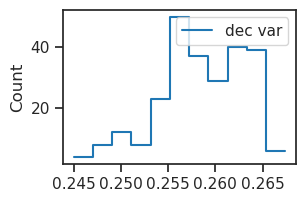

In [17]:
log_scale = tonp(tr.model.layer.log_scale.squeeze())
histplot(np.exp(log_scale) ** 2, label='dec var')
plt.legend();

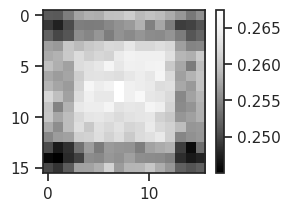

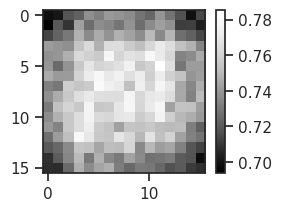

In [18]:
var = np.exp(log_scale) ** 2
var = var.reshape(16, 16)

var_data = tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze()

fig, ax =  create_figure()
imshow(var, cmap='Greys_r')
plt.colorbar()
plt.show()

fig, ax =  create_figure()
imshow(var_data, cmap='Greys_r')
plt.colorbar()
plt.show()

100%|███████████████████████████████████| 2/2 [01:23<00:00, 41.75s/it]


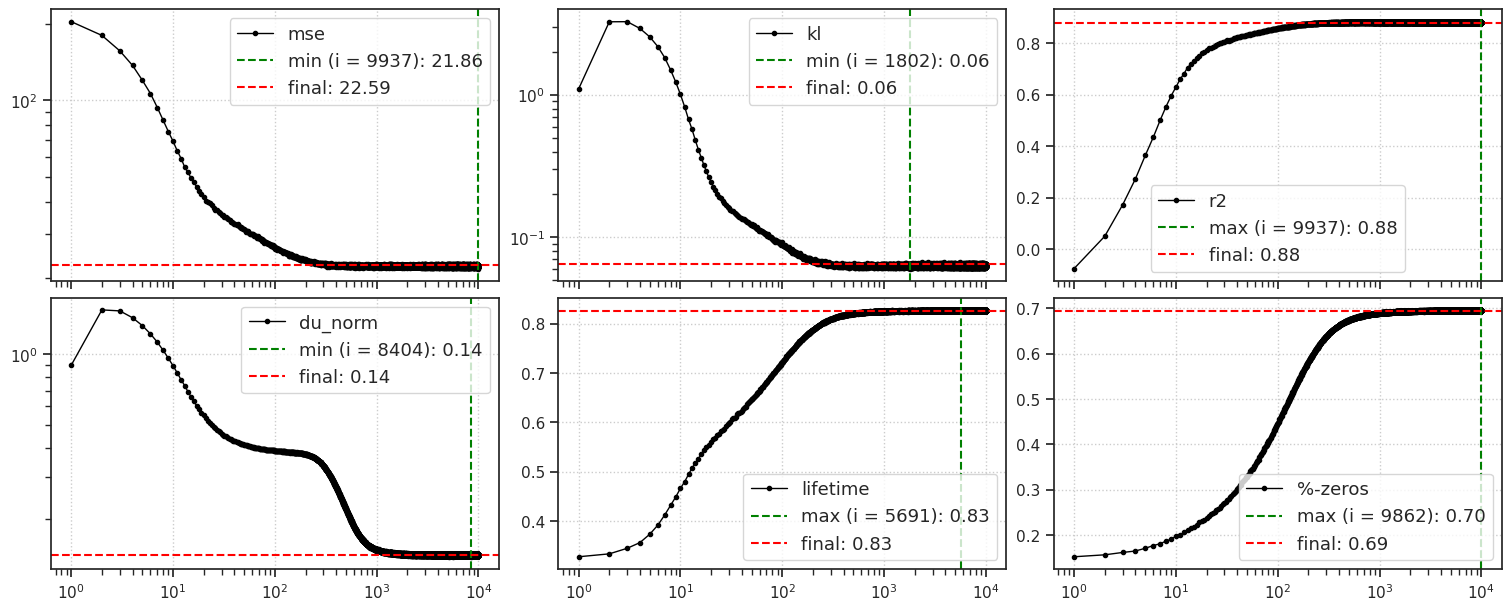

CPU times: user 1min 33s, sys: 1.32 s, total: 1min 34s
Wall time: 1min 34s


In [19]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

100%|█████████████████████████████████| 10/10 [07:17<00:00, 43.72s/it]


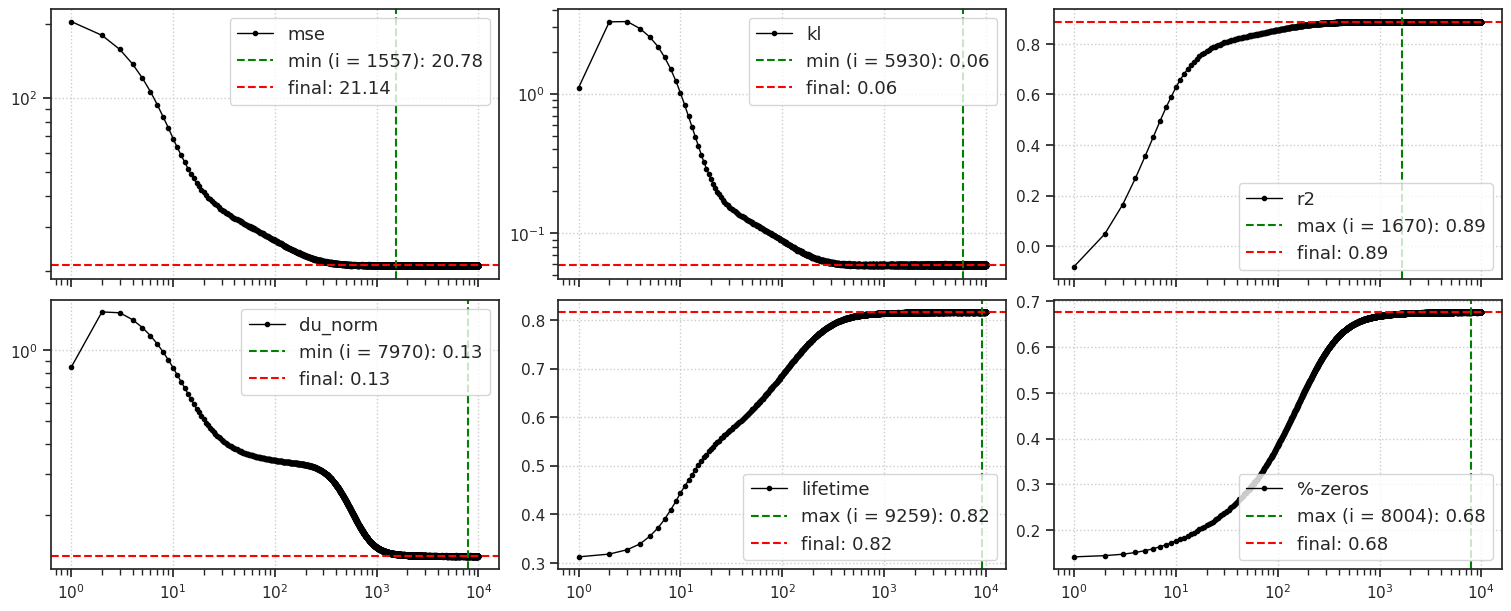

CPU times: user 7min 54s, sys: 23.7 s, total: 8min 18s
Wall time: 8min 18s


## output

In [20]:
%%time

output = tr.model.xtract_ftr(
    feeder=tr.get_feeder(),
    seq=range(1000),
    return_extras=True,
).stack()

print(list(output))

['loss_kl', 'loss_recon', 'posterior', 'du', 'u', 'v', 'recon', 'samples', 'conditional', 'mse', 'r2']

CPU times: user 3.92 s, sys: 7.97 ms, total: 3.93 s
Wall time: 3.93 s


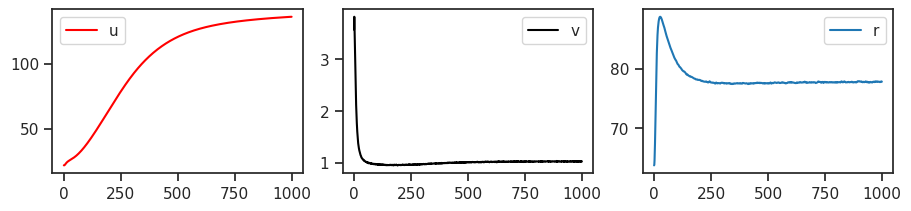

In [21]:
u_norm = tonp(torch.linalg.norm(output['u'], axis=-1).mean(0))
v_norm = tonp(torch.linalg.norm(output['v'], axis=-1).mean(0))
r_norm = tonp(torch.linalg.norm(torch.exp(output['u']), axis=-1).mean(0))

fig, axes = create_figure(1, 3)
axes[0].plot(u_norm, label='u', color='r')
axes[1].plot(v_norm, label='v', color='k')
axes[2].plot(r_norm, label='r')

add_legend(axes)
plt.show()

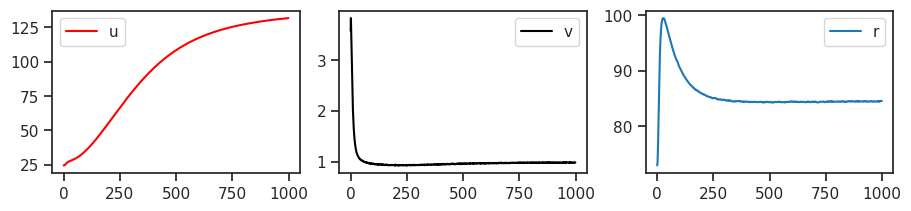

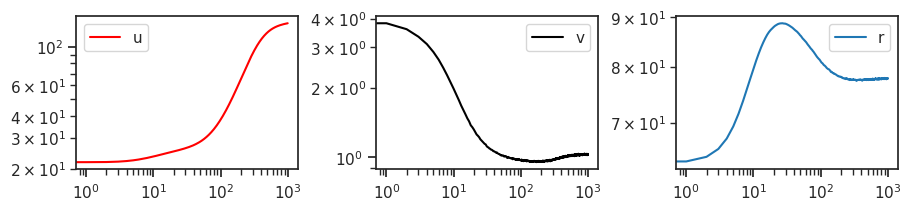

In [22]:
fig, axes = create_figure(1, 3)
axes[0].plot(u_norm, label='u', color='r')
axes[1].plot(v_norm, label='v', color='k')
axes[2].plot(r_norm, label='r')

for ax in axes.flat:
    ax.set(xscale='log', yscale='log')

add_legend(axes)
plt.show()

tensor([22.0602, 22.1268, 22.2973, 21.9066, 22.2343], device='cuda:0')

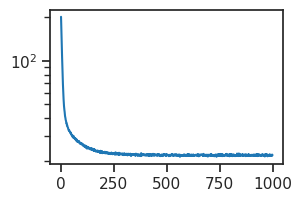

In [23]:
feeder = tr.get_feeder()

locs = torch.stack([
    p.loc for p in
    output['conditional'].values()
], dim=1)
mse = (locs - feeder[0].unsqueeze(1)).pow(2).sum(-1)
plot(mse.mean(0))
plt.yscale('log');

mse.mean(0)[-5:]

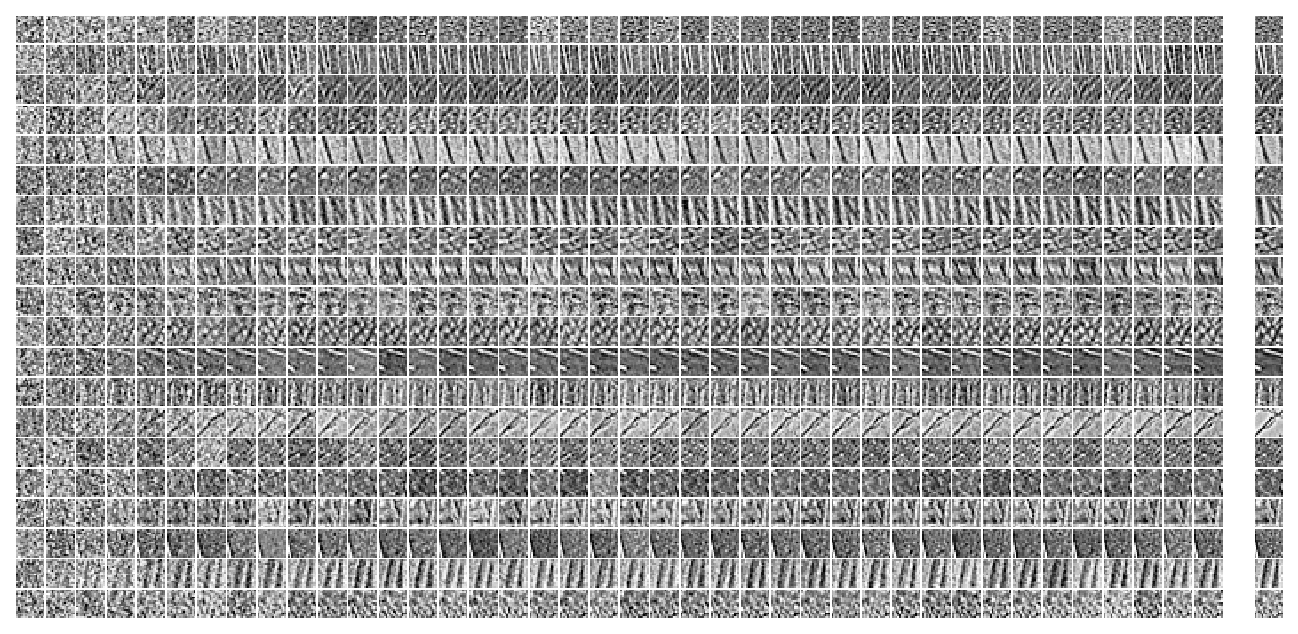

In [24]:
num = 20
n_timepoints = 40

x2p = tonp(locs)[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)

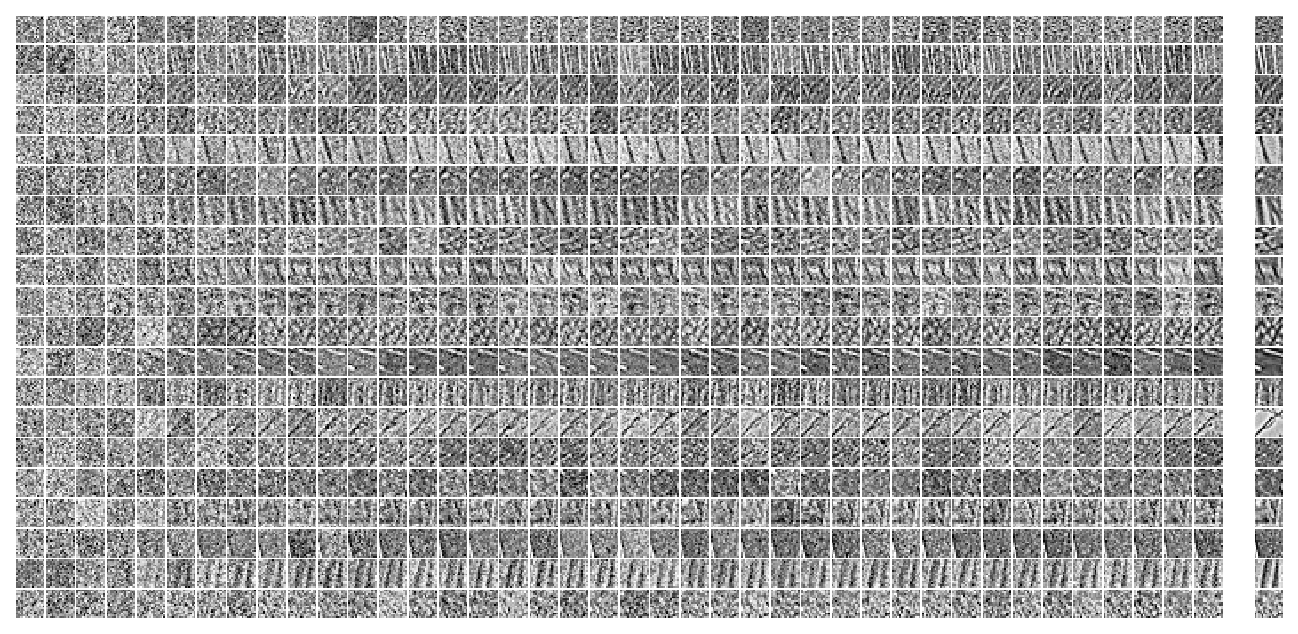

In [25]:
x2p = tonp(output['recon'])[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)